In [1]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,roc_curve
import joblib

In [2]:
# Load Dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Data Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop(columns=['customerID'],inplace= True)

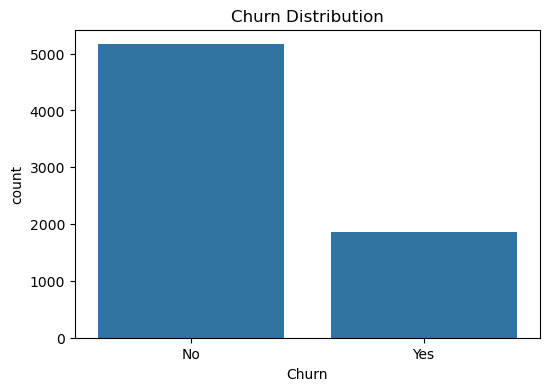

Churn Rate:
 Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [6]:
# EDA
# Countplot
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print("Churn Rate:\n", churn_rate)

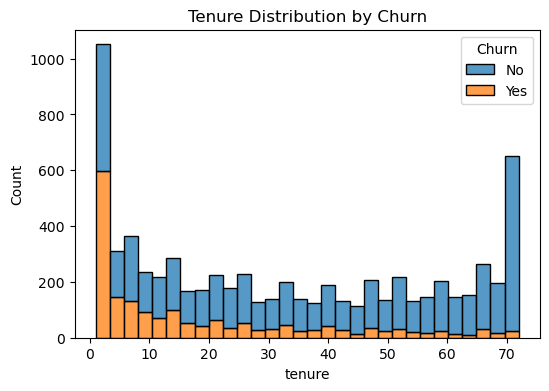

In [7]:
# Histogram
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure',hue='Churn',multiple='stack',bins=30)
plt.title('Tenure Distribution by Churn')
plt.show()

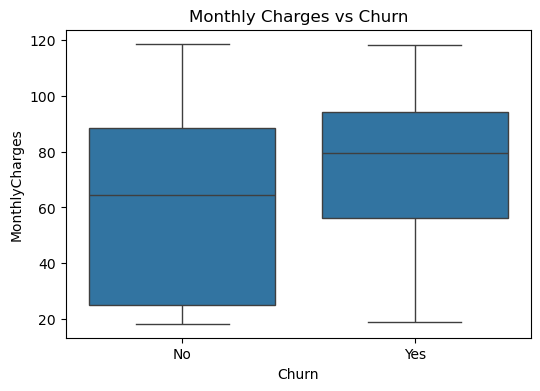

In [8]:
# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges',data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

In [9]:
# Features Scaling/Target Split
X = df.drop('Churn',axis = 1)
y = df['Churn'].map({'Yes':1, 'No':0})

In [10]:
# Column Transformer
num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_features),
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_features)
    ]
)

In [15]:
# Define Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder= False,eval_metric='logloss')
}

In [16]:
# Train/Test Split
X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [17]:
# Model Training and Evaluation
results = {}
for name, model in models.items():
    pipe =Pipeline(steps=[('preprocessor',preprocessor),('model',model)])
    pipe.fit(X_train,y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test,y_proba)
    print(f"\n{name} Classification Report:\n", classification_report(y_test,y_pred))
    print(f"{name} AUC: {auc:.4f}")
    results[name] = (pipe,auc)


Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Logistic Regression AUC: 0.8320

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.61      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.78      0.77      1407

Random Forest AUC: 0.8098

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.58      0.50      0.54       374

    acc

In [18]:
# Select Best Model
best_model_name = max(results, key= lambda k:results[k][1])
best_pipeline = results[best_model_name][0]
print(f"Best Model: {best_model_name} with AUC {results[best_model_name][1]:.4f}")

Best Model: Logistic Regression with AUC 0.8320


In [23]:
# Save Pipeline
joblib.dump(best_pipeline,'churn_pipeline.pkl')
print("Save best pipeline to churn_pipeline.pkl")

Save best pipeline to churn_pipeline.pkl


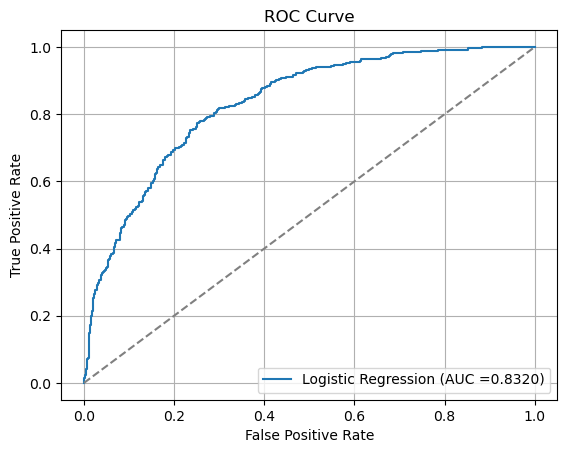

In [25]:
# ROC Curve for Best Model
fpr, tpr,_ = roc_curve(y_test,best_pipeline.predict_proba(X_test)[:,1])
plt.plot(fpr,tpr, label=f"{best_model_name} (AUC ={results[best_model_name][1]:.4f})")
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()